# Лабораторная работа 1

## Задача о падении тела. Построение графиков функций

*Радивилова Екатерина Сергеевна*, 25.02.2026

## Задание 1.1. Задача о падении тела

**Описание процесса**.
Тело запущено под углом $\alpha$ к горизонту на высоте $h_{start}$ и через
время $t=T$ достигает другое тело, расположенное на расстоянии $s_{end}$ и
высоте $h_{end}$. 

**Предположения**.

- Тело будем считать материальной точкой массы $m$.
- Движение осуществляется под действием силы тяжести
$$
{\bf F} = m(0,-g)
$$
где $m$ — масса тела, $g$ — ускорение свободного падения.
- Сопротивлением среды пренебрегаем.

**Данные**.
Задача рассматривается при следующих значениях параметров: $h_{start}$=1 m,
 $h_{end}$=3 m, $T$=3 s, $s_{end}$=5 m.
Угол запуска тела $\alpha$ не известен.
Начальный момент времени движения тела полагаем равным нулю: $t$= 0.
Значение массы тела $m$ не повлияет на функции перемещения тела.


**Выполнение задания 1.1**

**Этап 1. Импортирование модулей**


In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as const
import sympy


**Этап 2. Создание переменных**


In [4]:

h_start=1
h_end=3.0E+0
T=3.0
s_end=5.0e0
print(h_start, h_end)
print(' ')

g=const.g
g, const.unit('standard acceleration of gravity')

step=0.01
t_list=[0+i*step for i in range(int(T/step))]
t_array=np.arange(0, T, step)

1 3.0
 


**Этап 3. Определение функции перемещения и
нахождение угла запуска тела**


Полагаем, что начало прямоугольной декартовой системы координат соответствует
уровню земли. Тогда в начальный момент движения $t$ = 0 тела имеем, что 
$$
                     s_{x} = 0, s_{y} = h_{start}.
$$
Для построения функции перемещения ($s_{x}$(t), $s_{y}$(t)) воспользуемся вторым
законом Ньютона
$$
        ma=F,
$$
где $m$ — масса тела, ускорение движения тела **$a$**= ($s_{x}$''(t), $s_{y}$''(t))и приложенная
сила **$F$**=$m$(0, $-g$). В результате имеем два уравнения, что
$$
        s_{x}''(t)=0, s_{y}''(t)=-g.
$$
На основании уравнений с учетом начальных условий можно записать
аналитический вид для функций $s_{x}$(t) и $s_{y}$(t)
$$
    s_{x}(t)=s_{x}(0)+v0_{x}t=0+v0_{x}t,
$$
$$
    s_{y}(t)=s_{y}(0)+v0_{y}t=h_{start}+v0_{y}t-gt^2/2
$$

где $v0=(v0_{x}, v0_{y}) $ обозначает неизвестную скорость движения тела в начальный
момент времени $t$=0.


In [5]:
v0_x=s_end/T
v0_x

v0_y=(h_end-h_start+g/2*T**2)/T
v0_y

alpha=math.atan(v0_y/v0_x)
alpha, math.degrees(alpha)
f's_x(t) = {v0_x} t'
f's_y(t) = {h_start} + {v0_y:.6} t - {g:.6}/2*t\N{superscript two}'

's_y(t) = 1 + 15.3766 t - 9.80665/2*t²'

**Этап 4. Построение графика траектории движения тела**


(np.float64(0.0), np.float64(5.0), np.float64(0.0), np.float64(14.0))

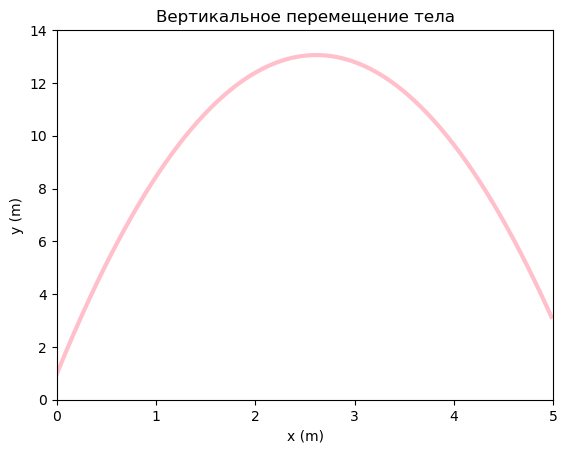

In [33]:
s_x_list=[v0_x*t for t in t_list]
s_y_list=[h_start+v0_y*t-g*t**2/2 for t in t_list]
s_x_array=v0_x*t_array
s_y_array=h_start+v0_y*t_array-g*t_array**2/2
plt.figure() ##создаёт новую фигуру для графика
plt.plot(s_x_array,s_y_array,color='pink',lw=3) ##строит линию с координатами x и y
plt.title('Вертикальное перемещение тела')
plt.xlabel('x (m)');
plt.ylabel('y (m)')
plt.axis([0, s_end, 0, h_end+11])

## Задание 1.2. Определение момента времени касания телом земли

**Подход 1:**

In [26]:
t= sympy.symbols('t')
result=sympy.solve(h_start+v0_y*t-g*t**2/2, t)
result
t_star_exact=result[-1]
t_star_exact

3.19970039267921

**Подход 2:**

In [27]:
t_stop=5
t_array_1=np.arange(0, t_stop, step)
s_y_array_1= h_start+v0_y*t_array_1-g*t_array_1**2/2
k=None
for i, j in enumerate(s_y_array_1[:-1]):
    if j*s_y_array_1[i+1]<0:
        k=i
        break
k

t1=t_array_1[k]
t2=t_array_1[k+1]
y1=s_y_array_1[k]
y2=s_y_array_1[k+1]

k_tilt=(y2-y1)/(t2-t1)
t_star_approx=t1-y1/k_tilt
t_star_approx

error=abs(t_star_exact-t_star_approx)/t_star_exact
error

2.79132127978774e-7

## Задание 1.3. Построение секущей, касательной и нормали к графику функции

Воспользуемся векторно-параметрическим уравнением прямой для заданной
точки $p_{start}$, лежащей на прямой, и заданного направляющего вектора $a$
$$
p(t)=p_{start}+at
$$
Направляющий вектор можно определить как $a=p_{end}-p_{start},$ где точка $p_{end}$
лежит на прямой и отлична от точки $p_{start}$.

In [40]:
p_start=np.array([s_x_array[0], s_y_array[0]])
p_end=np.array([s_x_array[-1], s_y_array[-1]])
p_start, p_end

(array([0., 1.]), array([4.98333333, 3.13994275]))

In [29]:
a=p_end-p_start
p=[p_start + a*t for t in [-1, 2]]
p=np.array(p)

Построим график траектории движения тела и график секущей

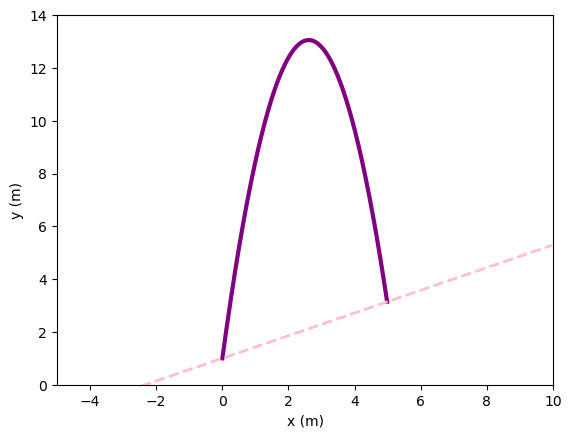

In [32]:
fig=plt.figure()
plt.plot(s_x_array, s_y_array, color= 'purple', lw=3)
plt.plot(p[:, 0], p[:, 1], '--', color='pink', lw=2)
plt.xlabel('x (m)'); plt.ylabel('y (m)')
plt.axis([-5, s_end+5, 0, h_end+11]);

Касательная в точке $t=0$ имеет наклон
$$
k=v0_y/v0_x
$$
Формула прямой:  
$$
y=k(x-x0)+y0
$$
Нормаль:
$$
k_{norm}=-1/k
$$

In [37]:
k_tg=v0_y/v0_x
x0, y0, =p_start
x_tg=np.array([x0-5, x0+5])
y_tg=k_tg*(x_tg-x0)+y0
k_norm=-1/k_tg
y_norm=k_norm*(x_tg-x0)+y0

График касательной прямой к траектории движения тела в одной
графической области с траекторией движения и секущей прямой.

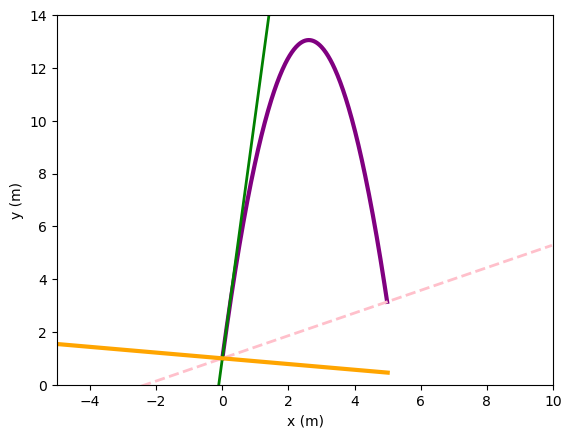

In [39]:
fig=plt.figure()
plt.plot(s_x_array, s_y_array, color= 'purple', lw=3)
plt.plot(p[:, 0], p[:, 1], '--', color='pink', lw=2)
plt.plot(x_tg, y_tg, color='green', lw=2)
plt.plot(x_tg, y_norm, color='orange', lw=3)
plt.xlabel('x (m)'); plt.ylabel('y (m)')
plt.axis([-5, s_end+5, 0, h_end+11]);

## Задание 1.4. Построение графиков функций

**Вариант 1**

a)

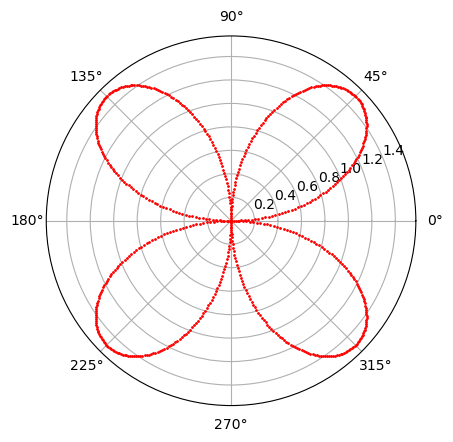

In [60]:
a=1
phi=np.arange(-np.pi, np.pi, 0.01)
rho=3*a/2*np.sin(2*phi)
phi_corr=phi+(rho<0)*np.pi
rho_corr=np.abs(rho)
plt.figure()
plt.axes(projection='polar')
plt.plot(phi_corr, rho_corr, 'r.', ms=2)

б)

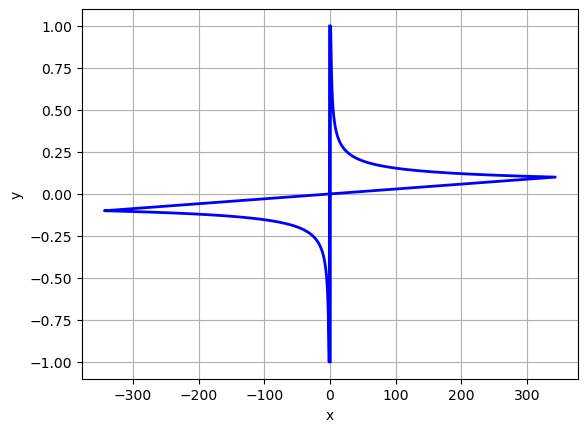

In [65]:
t1=np.linspace(-2, -0.1, 1000)
t2=np.linspace(0.1, 2, 1000)
t=np.concatenate((t1, t2))
x=(3*t**2+1)/(3*t**3)
y=np.sin(t**3/3+t)

plt.figure()
plt.plot(x, y, 'b-', lw=2)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)

**Вариант 2**

а)

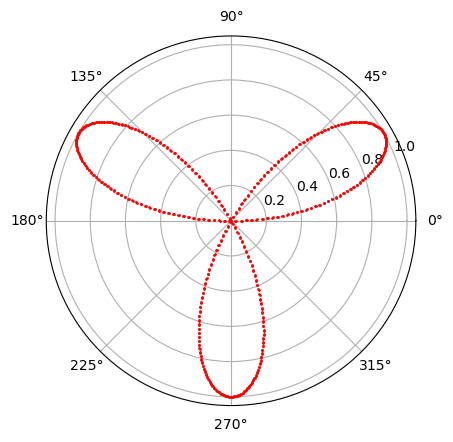

In [59]:
a=1
m=3
n=1
phi=np.arange(0, 2*np.pi, 0.01)
rho=a*np.sin((m/n)*phi)
phi_corr=phi+(rho<0)*np.pi
rho_corr=np.abs(rho)
plt.figure()
plt.axes(projection='polar')
plt.plot(phi_corr, rho_corr, 'r.', ms=2)

б)

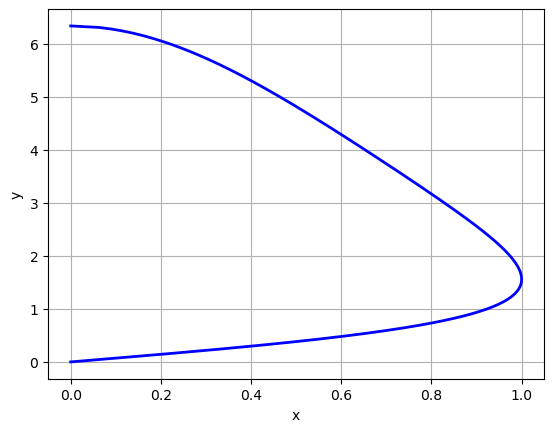

In [64]:
t=np.linspace(-1, 1, 1000)
x=np.sqrt(1-t**2)
y=np.tan(np.sqrt(1+t))

plt.figure()
plt.plot(x, y, 'b-', lw=2)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)

**Вариант 3**

а)

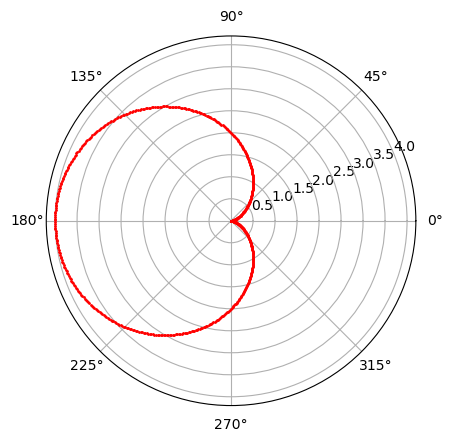

In [58]:
a=1
phi=np.arange(0, 2*np.pi, 0.01)
rho=2*a*(1-np.cos(phi))
phi_corr=phi+(rho<0)*np.pi
rho_corr=np.abs(rho)
plt.figure()
plt.axes(projection='polar')
plt.plot(phi_corr, rho_corr, 'r.', ms=2)

б)

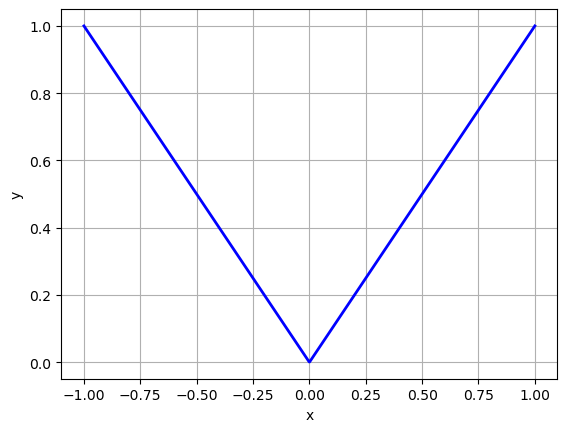

In [63]:
t=np.linspace(-1, 1, 1000)
x=np.arcsin(np.sin(t))
y=np.arccos(np.cos(t))
plt.figure()
plt.plot(x, y, 'b-', lw=2)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)

**Вариант 4**

а)

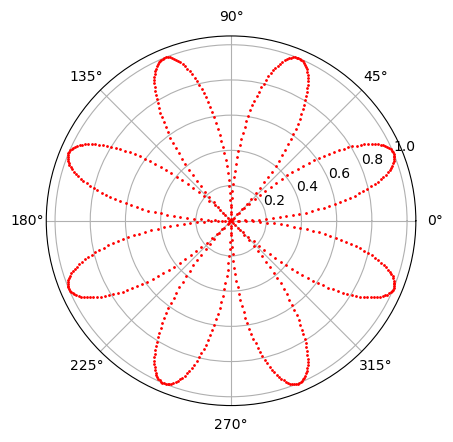

In [57]:
a=1
k=2
phi=np.arange(0, 2*np.pi, 0.01)
rho=a*np.sin(2*k*phi)
phi_corr=phi+(rho<0)*np.pi
rho_corr=np.abs(rho)
plt.figure()
plt.axes(projection='polar')
plt.plot(phi_corr, rho_corr, 'r.', ms=2)

б)

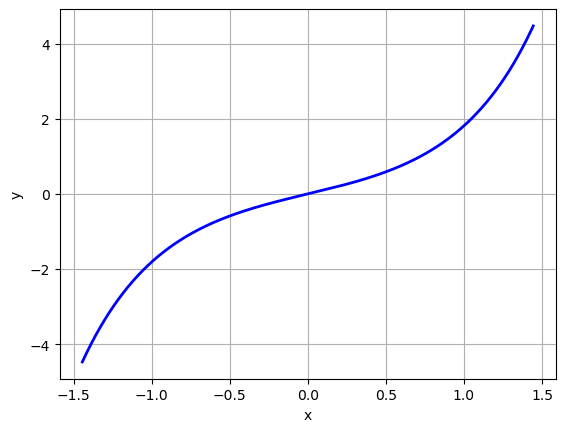

In [67]:
t=np.linspace(-2, 2, 2000)
x=np.log(t+np.sqrt(t**2+1))
y=t*np.sqrt(t**2+1)
plt.figure()
plt.plot(x, y, 'b-', lw=2)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)

**Вариант 5**

а)

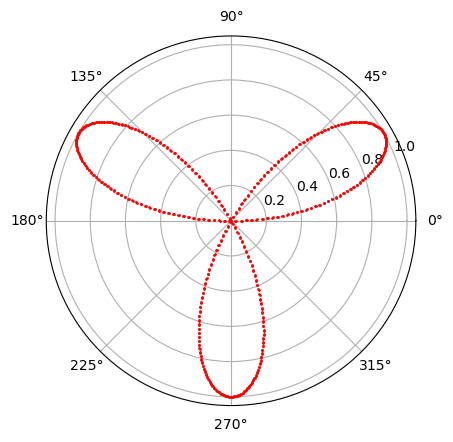

In [74]:
a=1
m=3
n=1
phi=np.arange(0, 2*np.pi, 0.01)
rho=a*np.sin((m/n)*phi)
phi_corr=phi+(rho<0)*np.pi
rho_corr=np.abs(rho)
plt.figure()
plt.axes(projection='polar')
plt.plot(phi_corr, rho_corr, 'r.', ms=2)

б)

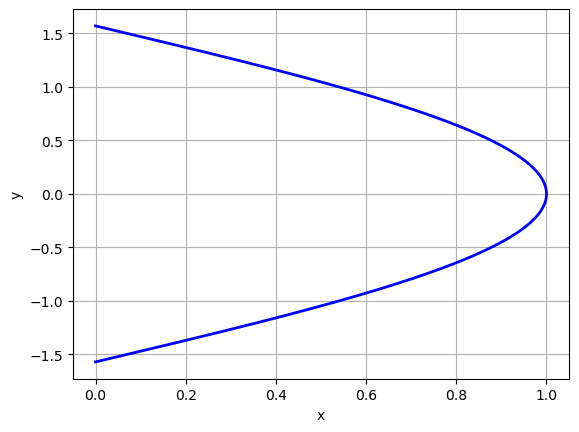

In [72]:
t=np.linspace(0, 2, 2000)
x=np.sqrt(2*t-t**2)
y=np.arcsin(t-1)
plt.figure()
plt.plot(x, y, 'b-', lw=2)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)

**Вариант 6**

а)

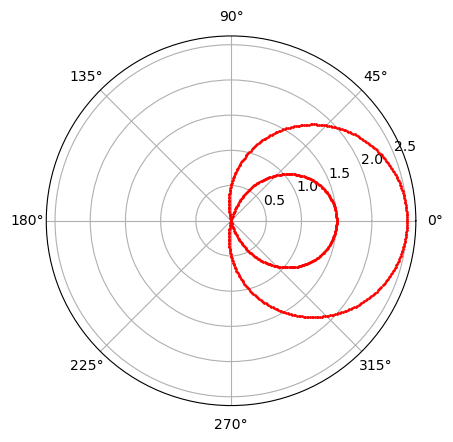

In [6]:
a=1
l=0.5
phi=np.arange(0, 2*np.pi, 0.01)
rho=2*a*np.cos(phi)+l
phi_corr=phi+(rho<0)*np.pi
rho_corr=np.abs(rho)
plt.figure()
plt.axes(projection='polar')
plt.plot(phi_corr, rho_corr, 'r.', ms=2)

б)

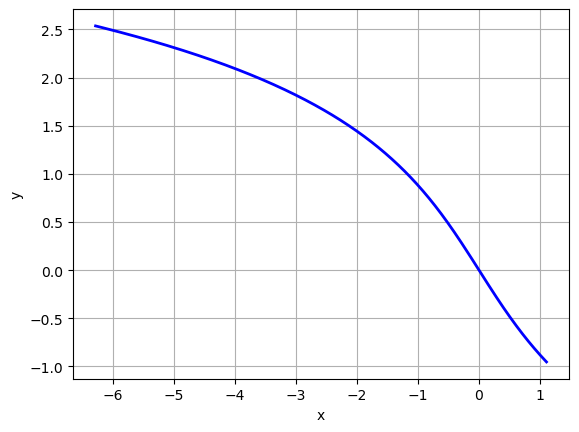

In [98]:
t=np.linspace(-1, 0.4, 2000)
exp=np.exp(t)
x=1/np.tan(2*exp)
y=np.log(np.tan(exp))
plt.figure()
plt.plot(x, y, 'b-', lw=2)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)

**Вариант 7**

а)

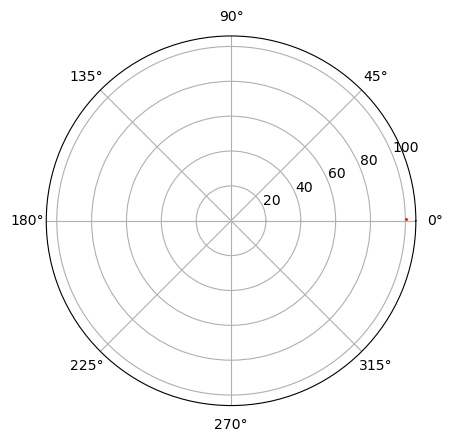

In [97]:
a=1
l=0.5
phi=np.arange(0.01, np.pi/2-0.1, 2000)
rho=a/np.sin(phi)+l
phi_corr=phi+(rho<0)*np.pi
rho_corr=np.abs(rho)
plt.figure()
plt.axes(projection='polar')
plt.plot(phi_corr, rho_corr, 'r.', ms=2)

б)

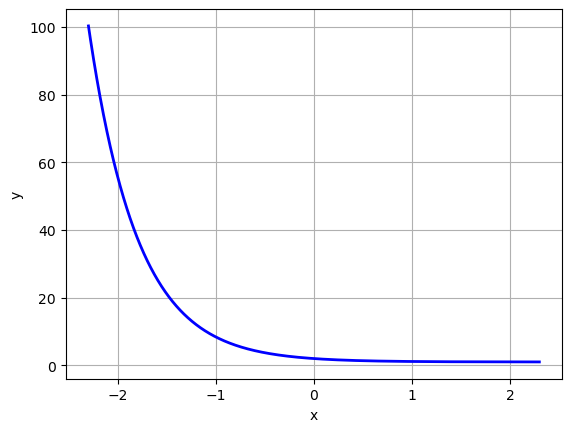

In [95]:
t=np.linspace(0.1, np.pi/2 - 0.1, 2000)
cot=1/np.tan(t)
x=np.log(cot)
y=1/(np.cos(t))**2
plt.figure()
plt.plot(x, y, 'b-', lw=2)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)

**Вариант 8**

а)

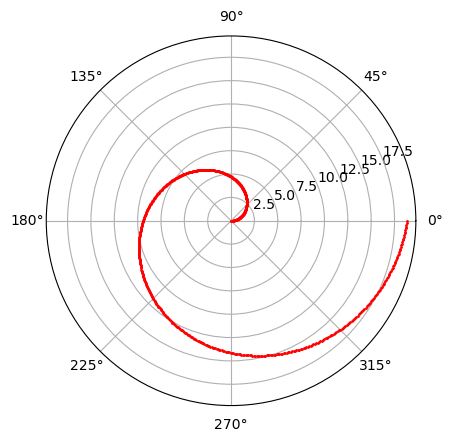

In [86]:
a=1
k=1
phi=np.arange(0, 2*np.pi, 0.01)
rho=a*((2*k+1)*phi)
phi_corr=phi+(rho<0)*np.pi
rho_corr=np.abs(rho)
plt.figure()
plt.axes(projection='polar')
plt.plot(phi_corr, rho_corr, 'r.', ms=2)

б)

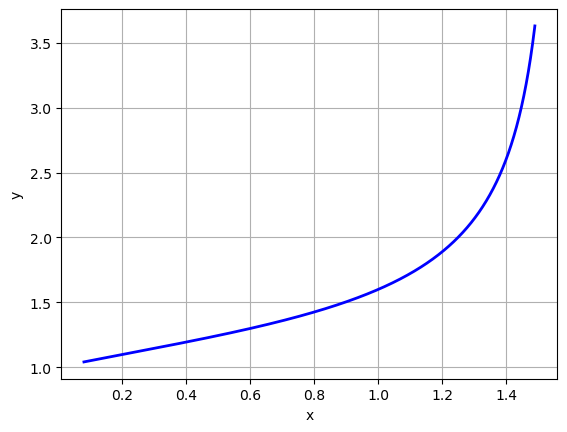

In [89]:
t=np.linspace(-5, 5, 2000)
x=np.arctan(np.exp(t/2))
y=np.sqrt(np.exp(t/2)+1)
plt.figure()
plt.plot(x, y, 'b-', lw=2)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)

**Вариант 9**

а)

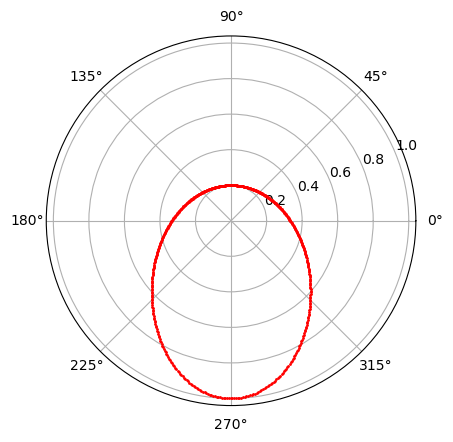

In [90]:
a=1
m=3
n=2
phi=np.arange(0, 2*np.pi, 0.01)
rho=a/(m+n*np.sin(phi))
phi_corr=phi+(rho<0)*np.pi
rho_corr=np.abs(rho)
plt.figure()
plt.axes(projection='polar')
plt.plot(phi_corr, rho_corr, 'r.', ms=2)

б)

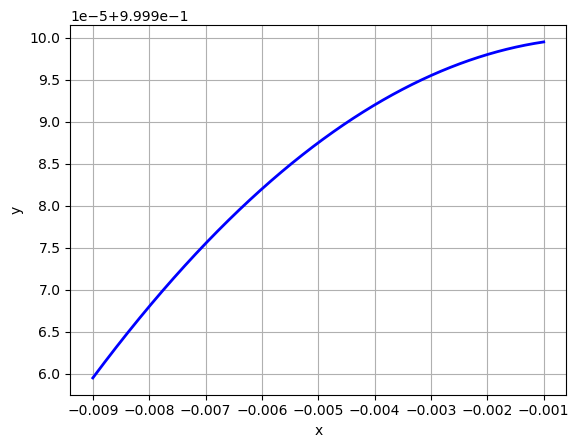

In [92]:
t=np.linspace(0.001, 0.009, 2000)
x=np.log(np.sqrt((1-t)/(1+t)))
y=np.sqrt(1-t**2)
plt.figure()
plt.plot(x, y, 'b-', lw=2)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)

**Вариант 10**

а)

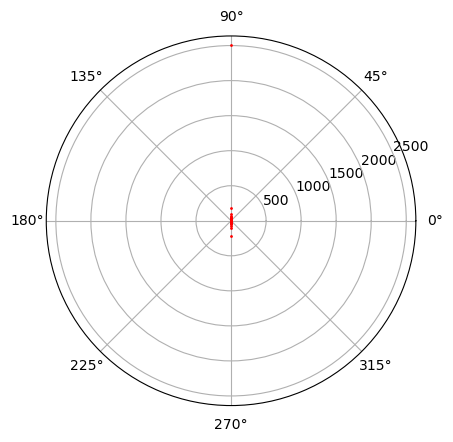

In [93]:
a=1
phi=np.arange(0, 2*np.pi, 0.01)
rho=a/np.cos(phi)+a*np.tan(phi)
phi_corr=phi+(rho<0)*np.pi
rho_corr=np.abs(rho)
plt.figure()
plt.axes(projection='polar')
plt.plot(phi_corr, rho_corr, 'r.', ms=2)

б)

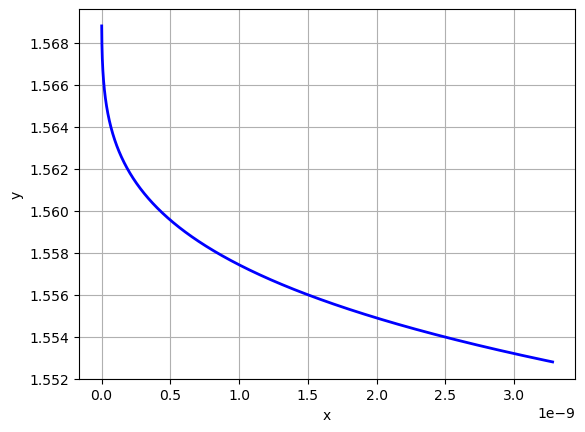

In [94]:
t=np.linspace(0.001, 0.009, 2000)
x=np.log(1/np.sqrt(1-t**4))
y=np.arcsin((1-t**2)/(1+t**2))
plt.figure()
plt.plot(x, y, 'b-', lw=2)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)